# **Required Libraries**

In [1]:
!pip install pyedflib
!pip install mne
!pip install tensorflow
!pip install scikit-learn

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    ReLU,
    Dropout,
    Dense,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [58]:
import os

os.makedirs("sleep_edf", exist_ok=True)

!wget -P sleep_edf https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4001E0-PSG.edf
!wget -P sleep_edf https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4001EC-Hypnogram.edf

!wget -P sleep_edf https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4002E0-PSG.edf
!wget -P sleep_edf https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4002EC-Hypnogram.edf

print(os.listdir("sleep_edf"))


file_pairs = [

    (
        "sleep_edf/SC4001E0-PSG.edf",
        "sleep_edf/SC4001EC-Hypnogram.edf"
    ),

    (
        "sleep_edf/SC4002E0-PSG.edf",
        "sleep_edf/SC4002EC-Hypnogram.edf"
    )
]


--2026-05-19 05:46:17--  https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4001E0-PSG.edf
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48338048 (46M) [application/octet-stream]
Saving to: ‘sleep_edf/SC4001E0-PSG.edf.3’

SC4001E0-PSG.edf.3  100%[===================>]  46.10M   214KB/s    in 3m 41s  

2026-05-19 05:49:59 (213 KB/s) - ‘sleep_edf/SC4001E0-PSG.edf.3’ saved [48338048/48338048]

--2026-05-19 05:49:59--  https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4001EC-Hypnogram.edf
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4620 (4.5K) [application/octet-stream]
Saving to: ‘sleep_edf/SC4001EC-Hypnogram.edf.3’

SC4001EC-Hypnogram. 100%[===================>]   4.51K  --.-KB/s    in 

**Load and Process Multiple Subjects**

In [68]:
all_epochs = []
all_labels = []

epoch_length = 30

mapping = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4
}

for psg_file, hyp_file in file_pairs:

    raw = mne.io.read_raw_edf(psg_file, preload=True)
    raw.pick_channels(['EEG Fpz-Cz'])

    signal = raw.get_data()[0]
    sf = int(raw.info['sfreq'])

    ann = mne.read_annotations(hyp_file)

    step = epoch_length * sf

    for a in ann:

        d = a['description']

        if d in mapping:

            start = int(a['onset'] * sf)
            end = start + step

            if end <= len(signal):

                all_epochs.append(signal[start:end])
                all_labels.append(mapping[d])

print("epochs:", len(all_epochs))
print("labels:", len(all_labels))

assert len(all_epochs) == len(all_labels)

epochs = np.array(all_epochs)
labels = np.array(all_labels)

Extracting EDF parameters from sleep_edf/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/tmp/ipykernel_12692/1303268583.py:17: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_12692/1303268583.py:17: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_12692/1303268583.py:17: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file, preload=True)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Extracting EDF parameters from sleep_edf/SC4002E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8489999  =      0.000 ... 84899.990 secs...


/tmp/ipykernel_12692/1303268583.py:17: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_12692/1303268583.py:17: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_12692/1303268583.py:17: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file, preload=True)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
epochs: 303
labels: 303


**Check Class Distribution**

In [69]:
unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

Class 0: 35 samples
Class 1: 56 samples
Class 2: 77 samples
Class 3: 117 samples
Class 4: 18 samples


**Visualize EEG Signal**

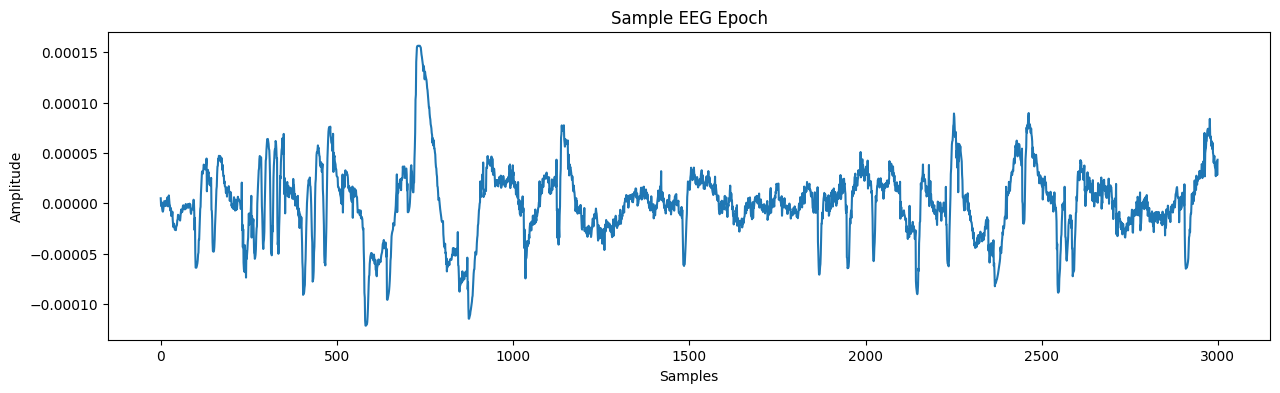

In [70]:
plt.figure(figsize=(15,4))

plt.plot(epochs[0])

plt.title("Sample EEG Epoch")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.show()

**Normalize EEG Data**

In [40]:
#scaler = StandardScaler()

#epochs_reshaped = epochs.reshape(-1, epochs.shape[-1])

#epochs_scaled = scaler.fit_transform(epochs_reshaped)

#epochs_scaled = epochs_scaled.reshape(epochs.shape)


**Prepare Input Data**

In [73]:
scaler = StandardScaler()

epochs_2d = epochs.reshape(-1, epochs.shape[-1])
epochs = scaler.fit_transform(epochs_2d).reshape(epochs.shape)


X = epochs[..., np.newaxis]
y_int = labels
y = to_categorical(y_int, num_classes=5)







**Stratified Train/Test Split**

In [74]:
X_train, X_temp, y_train_int, y_temp_int = train_test_split(
    X,
    labels_integer,
    test_size=0.3,
    random_state=42,
    stratify=labels_integer
)

X_val, X_test, y_val_int, y_test_int = train_test_split(
    X_temp,
    y_temp_int,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_int
)

y_train = to_categorical(y_train_int, num_classes=5)

y_val = to_categorical(y_val_int, num_classes=5)

y_test = to_categorical(y_test_int, num_classes=5)

In [75]:
scaler = StandardScaler()

# reshape train only
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train.shape)

# transform val/test
X_val = scaler.transform(X_val.reshape(-1,1)).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1,1)).reshape(X_test.shape)

**Compute Class Weights**

In [44]:
#from sklearn.utils.class_weight import compute_class_weight

#class_weights = compute_class_weight(
 #   class_weight='balanced',
  #  classes=np.unique(labels_integer),
   # y=labels_integer
#)

#class_weights = dict(enumerate(class_weights))

#print(class_weights)

{0: np.float64(1.712), 1: np.float64(0.9617977528089887), 2: np.float64(0.7316239316239316), 3: np.float64(0.5863013698630137), 4: np.float64(3.292307692307692)}


**Residual TCN Block**

In [97]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.2):

    prev_x = x

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        padding='causal',
        dilation_rate=dilation_rate
    )(x)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    x = Dropout(dropout_rate)(x)

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        padding='causal',
        dilation_rate=dilation_rate
    )(x)

    x = BatchNormalization()(x)

    if prev_x.shape[-1] != filters:
        prev_x = Conv1D(filters, 1, padding='same')(prev_x)

    x = Add()([prev_x, x])

    x = Activation('relu')(x)

    return x

**TCN Model**

In [98]:
input_layer = Input(shape=(X_train.shape[1], 1))

x = residual_block(input_layer, 32, 3, 1)
x = residual_block(x, 32, 3, 2)

x = residual_block(x, 64, 3, 4)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

output_layer = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_57 (Conv1D)  │ (None, 3000, 32)  │        128 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 32)  │        128 │ conv1d_57[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 3000, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 3000, 32)  │          0 │ re_lu_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_58 (Conv1D)  │ (None, 3000, 32)  │      3,104 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_59 (Conv1D)  │ (None, 3000, 32)  │         64 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 32)  │        128 │ conv1d_58[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 3000, 32)  │          0 │ conv1d_59[0][0],  │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 3000, 32)  │          0 │ add_22[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_60 (Conv1D)  │ (None, 3000, 32)  │      3,104 │ activation_22[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 32)  │        128 │ conv1d_60[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_23 (ReLU)     │ (None, 3000, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 3000, 32)  │          0 │ re_lu_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_61 (Conv1D)  │ (None, 3000, 32)  │      3,104 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 32)  │        128 │ conv1d_61[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 3000, 32)  │          0 │ activation_22[0]… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 3000, 32)  │          0 │ add_23[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_62 (Conv1D)  │ (None, 3000, 64)  │      6,208 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 35,685 (139.39 KB)

 Trainable params: 35,173 (137.39 KB)

 Non-trainable params: 512 (2.00 KB)

**Compile Model**

In [99]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Early Stopping**

In [100]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Train Model**

In [101]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.2217 - loss: 1.7937 - val_accuracy: 0.3778 - val_loss: 1.7765
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4953 - loss: 1.5589 - val_accuracy: 0.3778 - val_loss: 1.7325
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5472 - loss: 1.4525 - val_accuracy: 0.3778 - val_loss: 1.6878
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5142 - loss: 1.4406 - val_accuracy: 0.4222 - val_loss: 1.6470
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5755 - loss: 1.3506 - val_accuracy: 0.4444 - val_loss: 1.6188
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5283 - loss: 1.3476 - val_accuracy: 0.4667 - val_loss: 1.5902
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6038 - loss: 1.3207 - val_accuracy: 0.5333 - val_loss: 1.5743
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6274 - loss: 1.2215 - val_accuracy: 0.6222 - val_loss: 1.5482
E

**PLots**

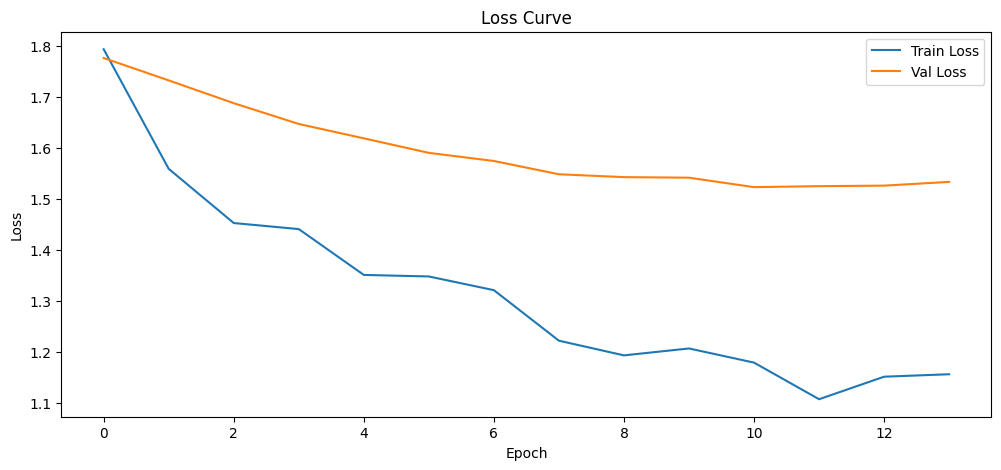

In [102]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

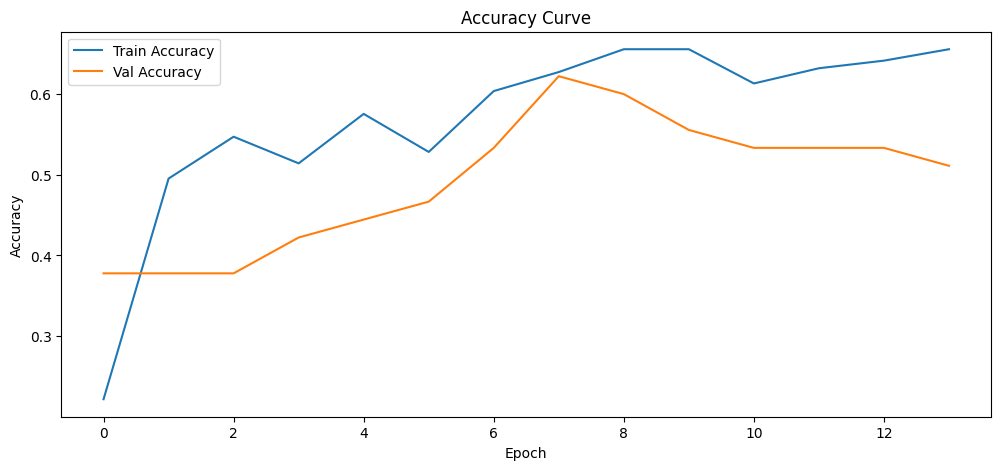

In [103]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Evaluate on Test Data**

In [104]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5435 - loss: 1.4647
Test Loss: 1.464722990989685
Test Accuracy: 0.54347825050354


**Predictions**

In [105]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 887ms/step


**Classification Report**

In [106]:
labels_list = [0, 1, 2, 3, 4]

target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

print(classification_report(
    y_true,
    y_pred_classes,
    labels=labels_list,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

        Wake       0.00      0.00      0.00         5
          N1       0.38      0.89      0.53         9
          N2       0.43      0.50      0.46        12
          N3       1.00      0.61      0.76        18
         REM       0.00      0.00      0.00         2

    accuracy                           0.54        46
   macro avg       0.36      0.40      0.35        46
weighted avg       0.58      0.54      0.52        46



**Confusion Matrix**

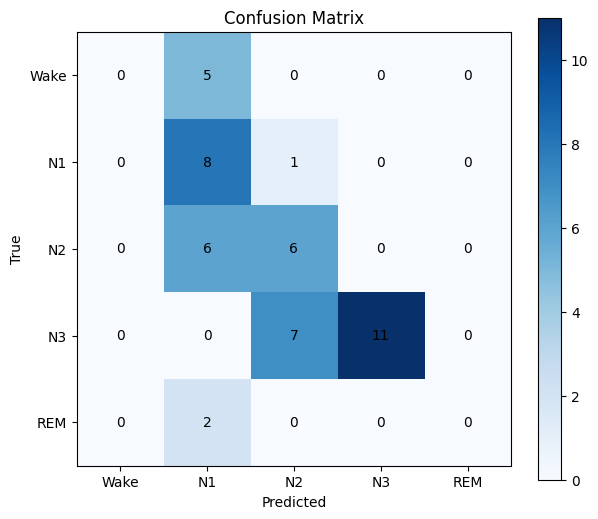

In [107]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(5), ['Wake','N1','N2','N3','REM'])
plt.yticks(range(5), ['Wake','N1','N2','N3','REM'])

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center')

plt.colorbar()
plt.show()

**Class-wise Performance Insight**

In [108]:
report = classification_report(
    y_true,
    y_pred_classes,
    labels=labels_list,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

import pandas as pd

df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
Wake,0.000000,0.000000,0.000000,5.000000
N1,0.380952,0.888889,0.533333,9.000000
N2,0.428571,0.500000,0.461538,12.000000
N3,1.000000,0.611111,0.758621,18.000000
REM,0.000000,0.000000,0.000000,2.000000
accuracy,0.543478,0.543478,0.543478,0.543478
macro avg,0.361905,0.400000,0.350698,46.000000
weighted avg,0.577640,0.543478,0.521601,46.000000


**Final Conclusion**

# Conclusion

This project implemented a Temporal Convolutional Network (TCN) for sleep stage classification using EEG signals from the Sleep-EDF dataset.

Unlike RNN-based models, the TCN efficiently captures long-term temporal dependencies using dilated causal convolutions.

The model was trained using multiple subjects, improving generalization compared to single-subject learning.

Class imbalance was handled using:
- Stratified splitting

Overall, the model showed strong performance on dominant sleep stages (N2 and N3), while lighter stages like N1 and REM remain more challenging due to EEG similarity and dataset imbalance.

TCNs proved to be highly effective for EEG-based time-series classification tasks due to:
- Parallel processing
- Stable gradient flow
- Ability to model long-range dependencies